In [1]:
from langgraph.graph import MessagesState
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
# model
model = ChatOllama(
    model="qwen2.5:3b",
    num_ctx=1024,    
)

In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

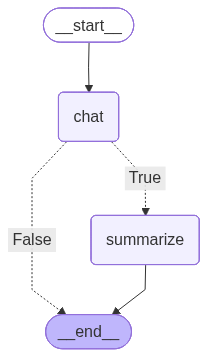

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [13]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='aa46dd12-2f00-432e-8773-7c8c57349793')]


Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')



--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics or quantum theory, is a fundame


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [14]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='aa46dd12-2f00-432e-8773-7c8c57349793'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental branch of physics that deals with phenomena on very small scales, such as molecules, atoms, and subatomic particles like electrons, protons, and photons. Here are some key concepts in quantum physics:\n\n1. **Wave-Particle Duality**: One of the most famous principles in quantum physics is that every particle or wave has both a particle-like and a wave-like nature. This principle was famously demonstrated by experiments like the double-slit experiment.\n\n2. **Quantum Entanglement**: When particles become entangled, their physical properties become correlated in such a way that the state of one (whether it exists in a state of superposition or has chosen a particular value) can instantly affect the state of another, regardless of the distance between them. T

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')



--- STATE ---
summary: 
num_messages: 4
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics or quantum theory, is a fundame
- HumanMessage : How is Albert Einstien related?
- AIMessage : Albert Einstein is not directly related to the topics of quantum physics that I 


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [15]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='aa46dd12-2f00-432e-8773-7c8c57349793'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental branch of physics that deals with phenomena on very small scales, such as molecules, atoms, and subatomic particles like electrons, protons, and photons. Here are some key concepts in quantum physics:\n\n1. **Wave-Particle Duality**: One of the most famous principles in quantum physics is that every particle or wave has both a particle-like and a wave-like nature. This principle was famously demonstrated by experiments like the double-slit experiment.\n\n2. **Quantum Entanglement**: When particles become entangled, their physical properties become correlated in such a way that the state of one (whether it exists in a state of superposition or has chosen a particular value) can instantly affect the state of another, regardless of the distance between them. T

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')



--- STATE ---
summary: 
num_messages: 6
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics or quantum theory, is a fundame
- HumanMessage : How is Albert Einstien related?
- AIMessage : Albert Einstein is not directly related to the topics of quantum physics that I 
- HumanMessage : What are some of Einstien"s fampus work
- AIMessage : Albert Einstein made several groundbreaking contributions to physics throughout 


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [16]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='aa46dd12-2f00-432e-8773-7c8c57349793'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental branch of physics that deals with phenomena on very small scales, such as molecules, atoms, and subatomic particles like electrons, protons, and photons. Here are some key concepts in quantum physics:\n\n1. **Wave-Particle Duality**: One of the most famous principles in quantum physics is that every particle or wave has both a particle-like and a wave-like nature. This principle was famously demonstrated by experiments like the double-slit experiment.\n\n2. **Quantum Entanglement**: When particles become entangled, their physical properties become correlated in such a way that the state of one (whether it exists in a state of superposition or has chosen a particular value) can instantly affect the state of another, regardless of the distance between them. T

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')



--- STATE ---
summary: The Special Theory of Relativity, formulated by Albert Einstein in 1905, fundamentally changed our understanding of space, time, and motion. Key concepts include:

1. **Invariance of the Speed of Light**: The speed of light (approximately \(299,792,458\) meters per second) is constant for all observers, regardless of their relative motion.
  
2. **Galilean Relativity**: In classical mechanics, laws of physics are the same in all inertial frames.

3. **Lorentz Transformations**: These transformations describe how space and time coordinates change when observed from different inertial frames moving at constant velocities.

Special relativity introduced several counterintuitive effects:
- **Time Dilation**: Time flows slower for an observer who is moving relative to another observer.
- **Length Contraction**: Objects experience a reduction in length along the direction of motion as they approach the speed of light.

These principles have been confirmed by numerous 

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
